In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from scipy.stats import spearmanr
from scipy.stats import mannwhitneyu

# 1) Folder setup (data in / outputs out)
DATA_DIR = Path("data")
OUT_DIR = Path("outputs")

DATA_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)


# 2) Helper functions
def clean_zip(value):
    """
    Convert a ZIP value into a clean 5-digit ZIP string.
    Returns np.nan if the value is missing or invalid.

    Handles:
    - floats like 90012.0
    - ZIP+4 like "90012-1234"
    - short ZIPs like "123" -> "00123"
    """
    if pd.isna(value):
        return np.nan

    s = str(value).strip()

    # Remove trailing ".0" if it came in as a float (common in CSVs)
    if s.endswith(".0"):
        s = s[:-2]

    # If ZIP+4 format, keep only the first 5 digits
    if "-" in s:
        s = s.split("-", 1)[0]

    # Keep only digits (in case of weird formatting like "90012 ")
    if not s.isdigit():
        return np.nan

    # Pad to 5 digits (e.g., "123" -> "00123")
    return s.zfill(5)


def find_first_col(df, candidates):
    """
    Find the first column in df that matches one of the candidate names
    (case-insensitive). Returns the actual column name or None.
    """
    # Map lowercase column name -> actual column name
    lower_to_actual = {col.lower(): col for col in df.columns}

    for name in candidates:
        key = name.lower()
        if key in lower_to_actual:
            return lower_to_actual[key]

    return None


def coerce_date(df, date_col):
    """
    Convert a date column into real datetime values.
    Invalid dates become NaT (missing).
    """
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    return df


def snapshot_asof(df, zip_col="zip", date_col="date", asof="2023-05-31"):
    """
    For each ZIP, keep the most recent row where date <= asof.
    Useful when you have daily/weekly time series data and want a single snapshot.

    Steps:
    1) Drop rows missing ZIP or date
    2) Keep only rows on/before the asof date
    3) For each ZIP, take the latest (max) date row
    """
    asof = pd.Timestamp(asof)

    # Work on a clean copy
    df = df.copy()

    # Drop rows missing ZIP/date
    df = df.dropna(subset=[zip_col, date_col])

    # Keep only rows up to the asof date
    df = df[df[date_col] <= asof]

    # Sort so the latest date per ZIP is at the bottom
    df = df.sort_values([zip_col, date_col])

    # Take the last row per ZIP (latest date)
    latest_per_zip = df.groupby(zip_col, as_index=False).tail(1)

    return latest_per_zip.reset_index(drop=True)

In [2]:
DATADESK_URL = "https://raw.githubusercontent.com/datadesk/california-coronavirus-data/master/cdph-vaccination-zipcode-totals.csv"
datadesk_raw = pd.read_csv(DATADESK_URL)

datadesk_raw.shape, datadesk_raw.head(3)

((143988, 11),
          date     id       county  fips  population  partially_vaccinated  \
 0  2021-08-17  90005  Los Angeles    37     39479.0                  3436   
 1  2021-08-17  90007  Los Angeles    37     41716.0                  3659   
 2  2021-08-17  90019  Los Angeles    37     66245.0                  5182   
 
    at_least_one_dose  fully_vaccinated  partially_vaccinated_percent  \
 0              26255             22819                          0.09   
 1              30782             27123                          0.09   
 2              42474             37292                          0.08   
 
    at_least_one_dose_percent  fully_vaccinated_percent  
 0                       0.67                      0.58  
 1                       0.74                      0.65  
 2                       0.64                      0.56  )

In [3]:
datadesk = datadesk_raw.copy()

# ZIP code (id column)
datadesk["zip"] = datadesk["id"].astype(str).str.zfill(5)

# Convert date column
datadesk["date"] = pd.to_datetime(datadesk["date"])

datadesk.head()

,date,id,county,fips,population,partially_vaccinated,at_least_one_dose,fully_vaccinated,partially_vaccinated_percent,at_least_one_dose_percent,fully_vaccinated_percent,zip
0,2021-08-17,90005,Los Angeles,37,39479.0,3436,26255,22819,0.09,0.67,0.58,90005
1,2021-08-17,90007,Los Angeles,37,41716.0,3659,30782,27123,0.09,0.74,0.65,90007
2,2021-08-17,90019,Los Angeles,37,66245.0,5182,42474,37292,0.08,0.64,0.56,90019
3,2021-08-17,90024,Los Angeles,37,50288.0,2386,25869,23483,0.05,0.51,0.47,90024
4,2021-08-17,90025,Los Angeles,37,47967.0,2774,33549,30775,0.06,0.70,0.64,90025


In [4]:
datadesk_la = datadesk[datadesk["county"] == "Los Angeles"].copy()

print("Rows:", len(datadesk_la))
print("Unique ZIPs:", datadesk_la["zip"].nunique())

Rows: 25618
Unique ZIPs: 276


In [5]:
start = pd.Timestamp("2021-08-01")
end = pd.Timestamp("2023-05-31")

datadesk_la = datadesk_la[
    (datadesk_la["date"] >= start) &
    (datadesk_la["date"] <= end)
].copy()

datadesk_la["date"].min(), datadesk_la["date"].max()

(Timestamp('2021-08-17 00:00:00'), Timestamp('2023-05-30 00:00:00'))

In [12]:
datadesk_la = datadesk_la.sort_values(["zip", "date"])

datadesk_snapshot = (
    datadesk_la
    .groupby("zip", as_index=False)
    .tail(1)
)
datadesk_snapshot = datadesk_snapshot.copy()
#you can increase or decrease the number from 20 if you wanna view more data
datadesk_snapshot.head(50)

,date,id,county,fips,population,partially_vaccinated,at_least_one_dose,fully_vaccinated,partially_vaccinated_percent,at_least_one_dose_percent,fully_vaccinated_percent,zip
142387,2023-05-30,90001,Los Angeles,37,58975.0,13713,58066,44353,0.23,0.98,0.75,90001
142388,2023-05-30,90002,Los Angeles,37,53111.0,5338,40763,35425,0.10,0.77,0.67,90002
142389,2023-05-30,90003,Los Angeles,37,72741.0,8531,57564,49033,0.12,0.79,0.67,90003
142390,2023-05-30,90004,Los Angeles,37,61586.0,5969,53241,47272,0.10,0.86,0.77,90004
142391,2023-05-30,90005,Los Angeles,37,39479.0,4436,33905,29469,0.11,0.86,0.75,90005
142392,2023-05-30,90006,Los Angeles,37,61698.0,6905,50835,43930,0.11,0.82,0.71,90006
142393,2023-05-30,90007,Los Angeles,37,41716.0,6220,41143,34923,0.15,0.99,0.84,90007
142394,2023-05-30,90008,Los Angeles,37,31739.0,2531,24395,21864,0.08,0.77,0.69,90008
142395,2023-05-30,90010,Los Angeles,37,3702.0,884,5136,4252,0.24,1.39,1.15,90010
142396,2023-05-30,90011,Los Angeles,37,109414.0,15483,85612,70129,0.14,0.78,0.64,90011


In [7]:
datadesk_snapshot["vax_rate"] = pd.to_numeric(
    datadesk_snapshot["fully_vaccinated_percent"],
    errors="coerce"
)

# Remove infinite values
datadesk_snapshot["vax_rate"].replace([np.inf, -np.inf], np.nan, inplace=True)

datadesk_snapshot["vax_rate"].describe()

/tmp/ipykernel_850/2241526977.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  datadesk_snapshot["vax_rate"].replace([np.inf, -np.inf], np.nan, inplace=True)


count    275.000000
mean       0.759891
std        0.114077
min        0.270000
25%        0.705000
50%        0.750000
75%        0.810000
max        1.660000
Name: vax_rate, dtype: float64

In [8]:
datadesk_snapshot["id"].unique()

array([90001, 90002, 90003, 90004, 90005, 90006, 90007, 90008, 90010,
       90011, 90012, 90013, 90014, 90015, 90016, 90017, 90018, 90019,
       90020, 90021, 90022, 90023, 90024, 90025, 90026, 90027, 90028,
       90029, 90031, 90032, 90033, 90034, 90035, 90036, 90037, 90038,
       90039, 90040, 90041, 90042, 90043, 90044, 90045, 90046, 90047,
       90048, 90049, 90056, 90057, 90058, 90059, 90061, 90062, 90063,
       90064, 90065, 90066, 90067, 90068, 90069, 90071, 90077, 90094,
       90201, 90210, 90211, 90212, 90220, 90221, 90222, 90230, 90232,
       90240, 90241, 90242, 90245, 90247, 90248, 90249, 90250, 90254,
       90255, 90260, 90262, 90263, 90265, 90266, 90270, 90272, 90274,
       90275, 90277, 90278, 90280, 90290, 90291, 90292, 90293, 90301,
       90302, 90303, 90304, 90305, 90401, 90402, 90403, 90404, 90405,
       90501, 90502, 90503, 90504, 90505, 90601, 90602, 90603, 90604,
       90605, 90606, 90638, 90640, 90650, 90660, 90670, 90701, 90703,
       90704, 90706,

In [17]:
datadesk_snapshot

,date,id,county,fips,population,partially_vaccinated,at_least_one_dose,fully_vaccinated,partially_vaccinated_percent,at_least_one_dose_percent,fully_vaccinated_percent,zip
142387,2023-05-30,90001,Los Angeles,37,58975.0,13713,58066,44353,0.23,0.98,0.75,90001
142388,2023-05-30,90002,Los Angeles,37,53111.0,5338,40763,35425,0.10,0.77,0.67,90002
142389,2023-05-30,90003,Los Angeles,37,72741.0,8531,57564,49033,0.12,0.79,0.67,90003
142390,2023-05-30,90004,Los Angeles,37,61586.0,5969,53241,47272,0.10,0.86,0.77,90004
142391,2023-05-30,90005,Los Angeles,37,39479.0,4436,33905,29469,0.11,0.86,0.75,90005
...,...,...,...,...,...,...,...,...,...,...,...,...
143147,2023-05-30,93550,Los Angeles,37,77006.0,5170,54215,49045,0.07,0.70,0.64,93550
143148,2023-05-30,93551,Los Angeles,37,51085.0,2921,39150,36229,0.06,0.77,0.71,93551
143149,2023-05-30,93552,Los Angeles,37,40266.0,2503,30546,28043,0.06,0.76,0.70,93552
143150,2023-05-30,93553,Los Angeles,37,1781.0,100,1061,961,0.06,0.60,0.54,93553


In [18]:
datadesk_snapshot.describe()

,date,id,fips,population,partially_vaccinated,at_least_one_dose,fully_vaccinated,partially_vaccinated_percent,at_least_one_dose_percent,fully_vaccinated_percent
count,276,276.000000,276.0,276.000000,276.000000,276.000000,276.000000,276.00,276.000,276.0000
mean,2023-05-30 00:00:00,90896.380435,37.0,36529.746377,3028.268116,30139.358696,27111.090580,inf,inf,inf
min,2023-05-30 00:00:00,90001.000000,37.0,0.000000,15.000000,150.000000,135.000000,0.03,0.390,0.2700
25%,2023-05-30 00:00:00,90221.750000,37.0,22752.000000,1665.500000,20121.750000,17849.500000,0.07,0.780,0.7075
50%,2023-05-30 00:00:00,90744.500000,37.0,33058.000000,2592.500000,27440.000000,25164.500000,0.08,0.825,0.7500
75%,2023-05-30 00:00:00,91364.750000,37.0,47213.750000,3832.250000,39183.000000,35112.750000,0.09,0.900,0.8100
max,2023-05-30 00:00:00,93591.000000,37.0,109414.000000,15483.000000,85612.000000,76941.000000,inf,inf,inf
std,NaN,829.766620,0.0,21157.941345,2104.965798,16567.529058,14763.626729,NaN,NaN,NaN


In [28]:
#finding infinite values
datadesk_snapshot['fully_vaccinated_percent'].max()

1.66

In [29]:
#identify how many rows
np.isinf(datadesk_snapshot['fully_vaccinated_percent']).sum()

0

In [30]:
#eliminated inifite value row
datadesk_snapshot['fully_vaccinated_percent'] = datadesk_snapshot['fully_vaccinated_percent'].replace([np.inf, -np.inf], np.nan)

In [26]:
datadesk_snapshot['fully_vaccinated_percent'].max()

1.66

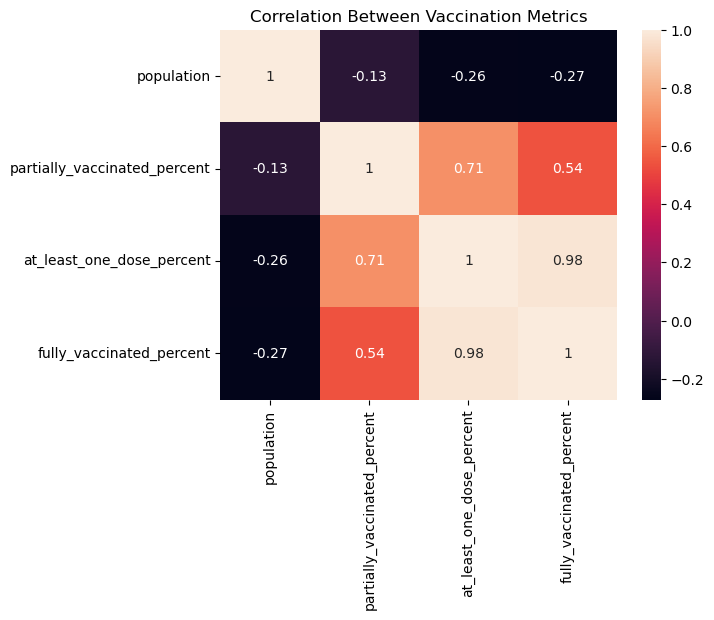

In [27]:
corr = datadesk_snapshot[[
    'population',
    'partially_vaccinated_percent',
    'at_least_one_dose_percent',
    'fully_vaccinated_percent'
]].corr()

sns.heatmap(corr, annot=True)

plt.title("Correlation Between Vaccination Metrics")
plt.show()

In [31]:
#Setting fully vaccinated max as 100%
datadesk_snapshot['fully_vaccinated_percent'] = datadesk_snapshot['fully_vaccinated_percent'].clip(upper=1)

In [32]:
#converting fully vaccinated to percentage
datadesk_snapshot['fully_vaccinated_percent'] = datadesk_snapshot['fully_vaccinated_percent'] * 100

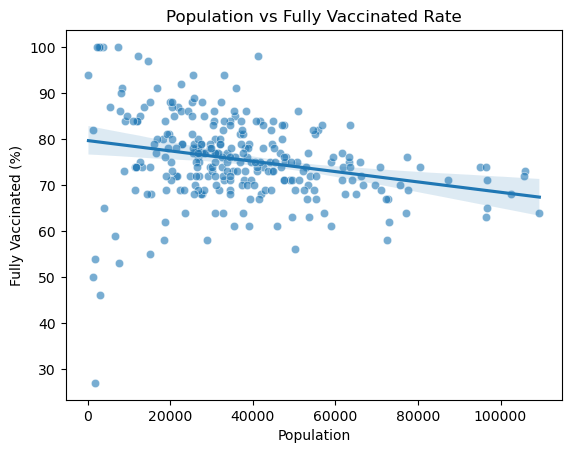

In [34]:
sns.scatterplot(
    data=datadesk_snapshot,
    x='population',
    y='fully_vaccinated_percent',
    alpha=0.6
)

sns.regplot(
    data=datadesk_snapshot,
    x='population',
    y='fully_vaccinated_percent',
    scatter=False
)

plt.title("Population vs Fully Vaccinated Rate")
plt.xlabel("Population")
plt.ylabel("Fully Vaccinated (%)")
plt.show()



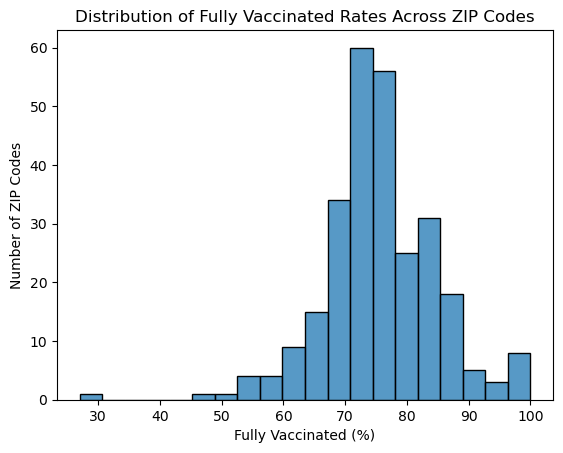

In [36]:
sns.histplot(
    data=datadesk_snapshot,
    x='fully_vaccinated_percent',
    bins=20
)

plt.title("Distribution of Fully Vaccinated Rates Across ZIP Codes")
plt.xlabel("Fully Vaccinated (%)")
plt.ylabel("Number of ZIP Codes")
plt.show()

In [43]:
#maxxing at least one dose at 100
datadesk_snapshot['at_least_one_dose_percent'] = datadesk_snapshot['at_least_one_dose_percent'].clip(upper=1)

In [44]:
#converting at least one dose to percentage
datadesk_snapshot['at_least_one_dose_percent'] = datadesk_snapshot['at_least_one_dose_percent'] * 100

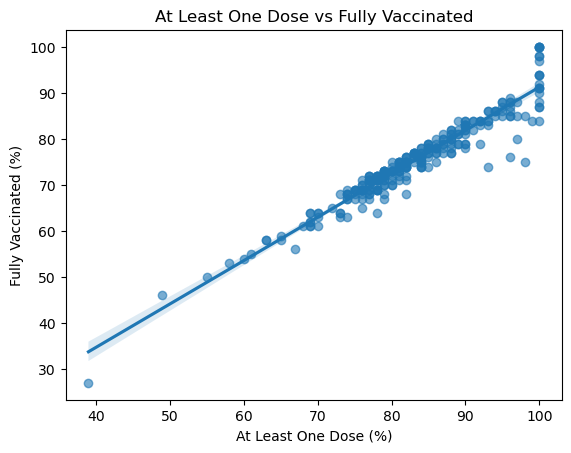

In [45]:
sns.regplot(
    data=datadesk_snapshot,
    x='at_least_one_dose_percent',
    y='fully_vaccinated_percent',
    scatter_kws={'alpha':0.6}
)

plt.title("At Least One Dose vs Fully Vaccinated")
plt.xlabel("At Least One Dose (%)")
plt.ylabel("Fully Vaccinated (%)")
plt.show()